In [32]:
"""
Density Plane Baryonic Response Visualization
==============================================

This notebook analyzes baryonic effects on 2D projected density fields (lenspots)
using the Mass-Radius-Redshift Response Formalism.

Key Equations (from baryonic-response-equations.md):
----------------------------------------------------
Eq (4) Cumulative Response:   F_S(M_min, α) = (S_R - S_D) / (S_H - S_D)
Eq (9) Tile Response:         ΔF_S(a,i) = (S_tile - S_D) / (S_H - S_D)  
Eq (12) Additive Approx:      F_S^(1) = Σ λ_{a,i} · ΔF_S(a,i)
Eq (13) Non-Additivity:       ε_S = (F_true - F^(1)) / F_true

Properties:

- F_S ≈ 0: Replace field mimics DMO (no baryonic effect captured)
- F_S ≈ 1: Replace field mimics Hydro (full baryonic effect captured)
- F_S < 0 or > 1: Non-linear effects or compensating contributions
"""

import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# # Style - publication quality
# plt.style.use('seaborn-v0_8-whitegrid')
# plt.rcParams.update({
#     'figure.figsize': (12, 8),
#     'font.size': 12,
#     'axes.labelsize': 14,
#     'axes.titlesize': 14,
#     'legend.fontsize': 10,
#     'figure.dpi': 100,
#     'savefig.dpi': 150,
#     'savefig.bbox': 'tight',
# })
import scienceplots

plt.style.use(['science', 'notebook'])
# Paths
STATS_CACHE_DIR = Path('./density_statistics_cache')
OUTPUT_DIR = Path('./density_response_output')
OUTPUT_DIR.mkdir(exist_ok=True)

print("=" * 60)
print("Density Plane Baryonic Response Analysis")
print("=" * 60)
print(f"Stats cache: {STATS_CACHE_DIR}")
print(f"Output dir:  {OUTPUT_DIR}")

Density Plane Baryonic Response Analysis
Stats cache: density_statistics_cache
Output dir:  density_response_output


## 1. Data Inventory

Check which models have completed statistics computation.

In [2]:
# Check for cached statistics
stats_files = sorted(STATS_CACHE_DIR.glob('*.h5')) if STATS_CACHE_DIR.exists() else []
print(f"Found {len(stats_files)} cached statistics files")

# Check for output files
output_files = sorted(OUTPUT_DIR.glob('*.h5')) if OUTPUT_DIR.exists() else []
output_figs = sorted(OUTPUT_DIR.glob('*.png')) if OUTPUT_DIR.exists() else []
print(f"Found {len(output_files)} output HDF5 files")
print(f"Found {len(output_figs)} output figures")

# List models with cached stats
if stats_files:
    models_with_stats = [f.stem.replace('_stats', '') for f in stats_files]
    print(f"\nModels with cached statistics ({len(models_with_stats)}):")
    for m in sorted(models_with_stats)[:10]:
        print(f"  - {m}")
    if len(models_with_stats) > 10:
        print(f"  ... and {len(models_with_stats) - 10} more")

Found 34 cached statistics files
Found 0 output HDF5 files
Found 34 output figures

Models with cached statistics (34):
  - dmo_density
  - hydro_density
  - hydro_replace_Ml_1.00e12_Mu_3.16e12_R_0.5_density
  - hydro_replace_Ml_1.00e12_Mu_3.16e12_R_1.0_density
  - hydro_replace_Ml_1.00e12_Mu_3.16e12_R_3.0_density
  - hydro_replace_Ml_1.00e12_Mu_3.16e12_R_5.0_density
  - hydro_replace_Ml_1.00e12_Mu_inf_R_0.5_density
  - hydro_replace_Ml_1.00e12_Mu_inf_R_1.0_density
  - hydro_replace_Ml_1.00e12_Mu_inf_R_3.0_density
  - hydro_replace_Ml_1.00e12_Mu_inf_R_5.0_density
  ... and 24 more


## 2. Load Baseline Statistics (DMO & Hydro)

These are the reference fields:
- **DMO** ($\rho_D$): Dark matter only simulation
- **Hydro** ($\rho_H$): Full hydrodynamic simulation with baryonic physics
- **$\Delta S = S_H - S_D$**: Total baryonic effect on statistic $S$

In [3]:
# Snapshot to redshift mapping (from copilot-instructions.md)
SNAPSHOT_LIST = [96, 90, 85, 80, 76, 71, 67, 63, 59, 56, 52, 49, 46, 43, 41, 38, 35, 33, 31, 29]
SNAPSHOT_TO_Z = {
    96: 0.02, 90: 0.10, 85: 0.18, 80: 0.27, 76: 0.35, 
    71: 0.46, 67: 0.55, 63: 0.65, 59: 0.76, 56: 0.85,
    52: 0.97, 49: 1.08, 46: 1.21, 43: 1.36, 41: 1.47,
    38: 1.63, 35: 1.82, 33: 1.97, 31: 2.14, 29: 2.32
}

# Select which snapshot to analyze (index 0-19 in our snapshot list)
# snapshot_id 0 = TNG snapshot 96 = z ≈ 0.02 (lowest redshift, most relevant for WL)
SELECTED_SNAPSHOT_ID = 0  
SELECTED_Z = SNAPSHOT_TO_Z[SNAPSHOT_LIST[SELECTED_SNAPSHOT_ID]]
print(f"Analyzing snapshot_id={SELECTED_SNAPSHOT_ID} -> TNG snap {SNAPSHOT_LIST[SELECTED_SNAPSHOT_ID]} -> z = {SELECTED_Z:.2f}")

def load_model_stats(model_name, stats_dir=STATS_CACHE_DIR, snapshot_id=SELECTED_SNAPSHOT_ID):
    """Load cached statistics for a model, filtered by snapshot_id.
    
    The files are named: {model}_density_stats.h5
    Structure (flat):
        - k: wavenumber bins
        - Pk: power spectra (n_samples, n_k)
        - pdf_bins: PDF bin centers
        - pdf: PDF values (n_samples, n_bins)
        - variance, skewness, kurtosis: moments (n_samples,)
        - snapshot_ids: which snapshot each sample comes from
    
    If snapshot_id is None, average over all samples.
    If snapshot_id is an int, filter to only that snapshot.
    """
    fpath = stats_dir / f"{model_name}_density_stats.h5"
    if not fpath.exists():
        return None
    
    with h5py.File(fpath, 'r') as f:
        k = f['k'][:]
        pdf_bins = f['pdf_bins'][:]
        
        if snapshot_id is not None and 'snapshot_ids' in f:
            # Filter by snapshot
            snap_ids = f['snapshot_ids'][:]
            mask = snap_ids == snapshot_id
            n_samples = np.sum(mask)
            
            if n_samples == 0:
                print(f"Warning: No samples for snapshot_id={snapshot_id} in {model_name}")
                return None
            
            Pk_all = f['Pk'][mask]
            pdf_all = f['pdf'][mask]
            var_all = f['variance'][mask]
            skew_all = f['skewness'][mask]
            kurt_all = f['kurtosis'][mask]
        else:
            # Use all samples
            n_samples = f['Pk'].shape[0]
            Pk_all = f['Pk'][:]
            pdf_all = f['pdf'][:]
            var_all = f['variance'][:]
            skew_all = f['skewness'][:]
            kurt_all = f['kurtosis'][:]
        
        # Average over filtered samples
        stats = {
            'k': k,
            'Pk': np.mean(Pk_all, axis=0),
            'Pk_std': np.std(Pk_all, axis=0),
            'pdf_bins': pdf_bins,
            'pdf_values': np.mean(pdf_all, axis=0),
            'variance': np.mean(var_all),
            'skewness': np.mean(skew_all),
            'kurtosis': np.mean(kurt_all),
            'n_samples': n_samples,
        }
    return stats

# Load DMO and Hydro baselines at selected redshift
dmo_stats = load_model_stats('dmo')
hydro_stats = load_model_stats('hydro')

if dmo_stats and hydro_stats:
    print(f"\n✓ Loaded DMO and Hydro baseline statistics at z = {SELECTED_Z:.2f}")
    print(f"  DMO: {dmo_stats['n_samples']} samples (10 LPs × 2 lenspots)")
    print(f"  Hydro: {hydro_stats['n_samples']} samples")
    print(f"  k range: {dmo_stats['k'].min():.3f} - {dmo_stats['k'].max():.1f} h/Mpc")
    print(f"  Number of k bins: {len(dmo_stats['k'])}")
else:
    print("⚠ Baseline statistics not yet available.")

Analyzing snapshot_id=0 -> TNG snap 96 -> z = 0.02

✓ Loaded DMO and Hydro baseline statistics at z = 0.02
  DMO: 20 samples (10 LPs × 2 lenspots)
  Hydro: 20 samples
  k range: 0.037 - 88.8 h/Mpc
  Number of k bins: 2896


## 3. Power Spectrum: Baseline Comparison

The 2D power spectrum $P(k)$ shows how baryonic physics redistributes matter:
- **Large scales** (small $k$): Little effect - gravity dominates
- **Small scales** (large $k$): **Suppression** from AGN feedback ejecting gas from halos

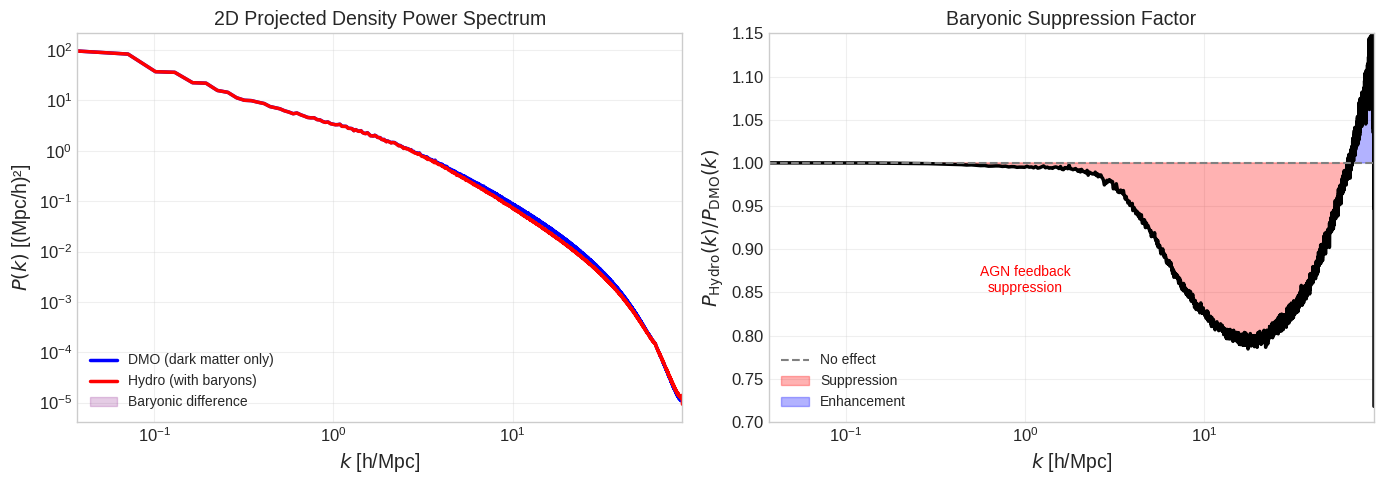


Key suppression values:
  k = 0.10 h/Mpc: P_H/P_D = 1.000 (-0.0%)
  k = 0.50 h/Mpc: P_H/P_D = 0.998 (-0.2%)
  k = 0.99 h/Mpc: P_H/P_D = 0.995 (-0.5%)
  k = 5.01 h/Mpc: P_H/P_D = 0.919 (-8.1%)
  k = 10.01 h/Mpc: P_H/P_D = 0.828 (-17.2%)


In [4]:
if dmo_stats and hydro_stats:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    k = dmo_stats['k']
    Pk_dmo = dmo_stats['Pk']
    Pk_hydro = hydro_stats['Pk']
    
    # Left: Absolute power spectra
    ax = axes[0]
    ax.loglog(k, Pk_dmo, 'b-', lw=2.5, label='DMO (dark matter only)')
    ax.loglog(k, Pk_hydro, 'r-', lw=2.5, label='Hydro (with baryons)')
    ax.fill_between(k, Pk_dmo, Pk_hydro, alpha=0.2, color='purple', 
                     label='Baryonic difference')
    ax.set_xlabel(r'$k$ [h/Mpc]')
    ax.set_ylabel(r'$P(k)$ [(Mpc/h)²]')
    ax.set_title('2D Projected Density Power Spectrum')
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(k.min(), k.max())
    
    # Right: Ratio (suppression factor)
    ax = axes[1]
    ratio = Pk_hydro / Pk_dmo
    ax.semilogx(k, ratio, 'k-', lw=2.5)
    ax.axhline(1.0, color='gray', ls='--', lw=1.5, label='No effect')
    ax.fill_between(k, 1.0, ratio, where=(ratio < 1), alpha=0.3, color='red',
                    label='Suppression')
    ax.fill_between(k, 1.0, ratio, where=(ratio > 1), alpha=0.3, color='blue',
                    label='Enhancement')
    ax.set_xlabel(r'$k$ [h/Mpc]')
    ax.set_ylabel(r'$P_{\rm Hydro}(k) / P_{\rm DMO}(k)$')
    ax.set_title('Baryonic Suppression Factor')
    ax.set_ylim(0.7, 1.15)
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(k.min(), k.max())
    
    # Add annotation for key scales
    ax.annotate('AGN feedback\nsuppression', xy=(1.0, 0.85), fontsize=10,
                ha='center', color='red')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'baseline_power_spectrum.png')
    plt.show()
    
    # Print key numbers
    print(f"\nKey suppression values:")
    for k_target in [0.1, 0.5, 1.0, 5.0, 10.0]:
        idx = np.argmin(np.abs(k - k_target))
        print(f"  k = {k[idx]:.2f} h/Mpc: P_H/P_D = {ratio[idx]:.3f} ({(ratio[idx]-1)*100:+.1f}%)")
else:
    print("⚠ Statistics not available yet. Run driver_density_response_mpi.py first.")

## 4. Density PDF: Baseline Comparison

The probability distribution function (PDF) of $\log_{10}(1+\delta)$ reveals how baryons modify the density field:
- **Underdense regions** (left tail): Voids slightly affected
- **Mean density** (peak): Shifted by mass redistribution  
- **Overdense regions** (right tail): Halos modified by feedback

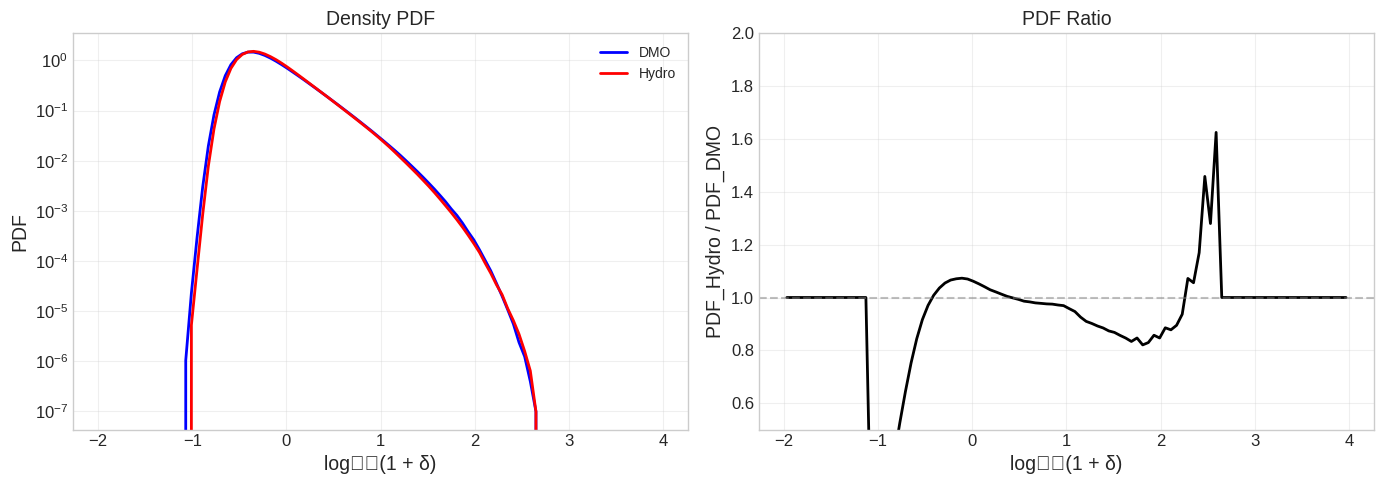

In [5]:
if dmo_stats and hydro_stats:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: PDF
    ax = axes[0]
    ax.semilogy(dmo_stats['pdf_bins'], dmo_stats['pdf_values'], 'b-', lw=2, label='DMO')
    ax.semilogy(hydro_stats['pdf_bins'], hydro_stats['pdf_values'], 'r-', lw=2, label='Hydro')
    ax.set_xlabel('log₁₀(1 + δ)')
    ax.set_ylabel('PDF')
    ax.set_title('Density PDF')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Right: PDF ratio
    ax = axes[1]
    valid = dmo_stats['pdf_values'] > 1e-10
    ratio = np.ones_like(dmo_stats['pdf_values'])
    ratio[valid] = hydro_stats['pdf_values'][valid] / dmo_stats['pdf_values'][valid]
    ax.plot(dmo_stats['pdf_bins'], ratio, 'k-', lw=2)
    ax.axhline(1.0, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel('log₁₀(1 + δ)')
    ax.set_ylabel('PDF_Hydro / PDF_DMO')
    ax.set_title('PDF Ratio')
    ax.set_ylim(0.5, 2.0)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Statistics not available yet.")

## 5. Moments Summary: Baseline Comparison

Higher-order moments capture non-Gaussian features of the density field.

In [6]:
if dmo_stats and hydro_stats:
    print("Density Field Moments (of overdensity δ):")
    print("=" * 60)
    print(f"{'Statistic':<15} {'DMO':>12} {'Hydro':>12} {'H/D Ratio':>12} {'ΔS/S_D':>12}")
    print("-" * 60)
    
    for name in ['variance', 'skewness', 'kurtosis']:
        dmo_val = dmo_stats[name]
        hydro_val = hydro_stats[name]
        ratio = hydro_val / dmo_val if dmo_val != 0 else np.nan
        frac_change = (hydro_val - dmo_val) / np.abs(dmo_val) if dmo_val != 0 else np.nan
        print(f"{name.capitalize():<15} {dmo_val:>12.4f} {hydro_val:>12.4f} {ratio:>12.4f} {frac_change:>+12.1%}")
    
    print("-" * 60)
    print("\nInterpretation:")
    var_change = (hydro_stats['variance'] - dmo_stats['variance']) / dmo_stats['variance']
    if var_change < 0:
        print(f"  • Variance reduced by {-var_change:.1%} → baryons smooth the density field")
    else:
        print(f"  • Variance increased by {var_change:.1%} → baryons enhance density contrasts")
else:
    print("⚠ Statistics not available yet.")

Density Field Moments (of overdensity δ):
Statistic                DMO        Hydro    H/D Ratio       ΔS/S_D
------------------------------------------------------------
Variance              4.7266       4.2769       0.9049        -9.5%
Skewness             19.9332      21.1526       1.0612        +6.1%
Kurtosis            914.5516    1107.7363       1.2112       +21.1%
------------------------------------------------------------

Interpretation:
  • Variance reduced by 9.5% → baryons smooth the density field


---
# Response Fraction Analysis

## 6. Cumulative Response Fraction $F_S(M_{\min}, \alpha)$

**Equation (4):** The cumulative response fraction measures what fraction of the total baryonic effect is captured by replacing halos above mass $M_{\min}$ out to radius $\alpha \times R_{200}$:

$$F_S(M_{\min}, \alpha) = \frac{S_R - S_D}{S_H - S_D}$$

**Interpretation:**
- $F_S \approx 0$: Replace field ≈ DMO (halos above $M_{\min}$ contribute nothing)
- $F_S \approx 1$: Replace field ≈ Hydro (halos above $M_{\min}$ capture full effect)
- $F_S > 1$: Overshooting (lower-mass halos have compensating negative contribution)

In [112]:
# Configuration: Mass bins and radius factors
# We ONLY use cumulative models and derive differential contributions by subtraction

MASS_THRESHOLDS = ['1.00e12', '3.16e12', '1.00e13', '3.16e13']  # M_min values
MASS_LABELS = [r'$10^{12.0}$', r'$10^{12.5}$', r'$10^{13.0}$', r'$10^{13.5}$']
LOG_MASS = [12.0, 12.5, 13.0, 13.5]

RADII = ['0.5', '1.0', '3.0', '5.0']
ALPHA_VALUES = [0.5, 1.0, 3.0, 5.0]

# Threshold for significant baryonic effect
# If |P_H - P_D| < THRESHOLD * |P_D|, we consider F ≈ undefined (no significant effect)
BARYONIC_THRESHOLD = 0.01  # 1% relative difference required
NYQUIST = np.pi *4096/ 205

def compute_response_fraction_k(replace_stats, dmo_stats, hydro_stats, threshold=BARYONIC_THRESHOLD):
    """
    Compute scale-dependent response fraction F_S(k).

    F_S(k) = (P_R(k) - P_D(k)) / (P_H(k) - P_D(k))

    Returns F(k) array with NaN where |ΔP| < threshold * |P_D|
    """
    if replace_stats is None:
        return None

    P_r = replace_stats['Pk']
    P_d = dmo_stats['Pk']
    P_h = hydro_stats['Pk']
    k = dmo_stats['k']

    Delta_P = P_h - P_d

    # Mask where baryonic effect is too small (noisy) and below nyquist
    significant = (np.abs(Delta_P) > threshold * np.abs(P_d)) & (k < NYQUIST)
    print(k[significant][0], k[significant][-1])

    F_k = np.full_like(P_d, np.nan)
    F_k[significant] = (P_r[significant] - P_d[significant]) / Delta_P[significant]

    return F_k

def compute_response_fraction_scalar(replace_stats, dmo_stats, hydro_stats, stat_name, threshold=BARYONIC_THRESHOLD):
    """
    Compute response fraction for a scalar statistic (variance, etc.)

    Returns NaN if baryonic effect is too small.
    """
    if replace_stats is None:
        return np.nan

    S_r = replace_stats[stat_name]
    S_d = dmo_stats[stat_name]
    S_h = hydro_stats[stat_name]
    k = dmo_stats['k']

    Delta_S = S_h - S_d

    # Check if baryonic effect is significant
    if (np.abs(Delta_S) < threshold * np.abs(S_d)) & (k < NYQUIST):
        return np.nan  # No significant baryonic effect

    return (S_r - S_d) / Delta_S

def compute_response_fraction_Pk_mean(replace_stats, dmo_stats, hydro_stats, k_range=(1.0, 30.0)):
    """
    Compute mean response fraction for P(k) over a k-range where baryonic effects are significant.

    Uses weighted average where weights = |ΔP(k)|
    """
    if replace_stats is None:
        return np.nan

    k = dmo_stats['k']
    P_r = replace_stats['Pk']
    P_d = dmo_stats['Pk']
    P_h = hydro_stats['Pk']

    Delta_P = P_h - P_d

    # Select k-range and where effect is significant
    in_range = (k >= k_range[0]) & (k <= NYQUIST)
    significant = (np.abs(Delta_P) > BARYONIC_THRESHOLD * np.abs(P_d)) & (k < NYQUIST)
    valid = in_range & significant

    if np.sum(valid) == 0:
        return np.nan

    F_k = (P_r[valid] - P_d[valid]) / Delta_P[valid]
    weights = np.abs(Delta_P[valid])

    return np.average(F_k, weights=weights)

def compute_response_fraction_Pk_mean_std(replace_stats, dmo_stats, hydro_stats, k_range=(1.0, 30.0)):
    """Return weighted mean and weighted std of F(k) over the chosen k-range."""
    if replace_stats is None:
        return np.nan, np.nan

    k = dmo_stats['k']
    P_r = replace_stats['Pk']
    P_d = dmo_stats['Pk']
    P_h = hydro_stats['Pk']

    Delta_P = P_h - P_d

    in_range = (k >= k_range[0]) & (k <= NYQUIST)
    significant = (np.abs(Delta_P) > BARYONIC_THRESHOLD * np.abs(P_d)) & (k < NYQUIST)
    valid = in_range & significant

    if np.sum(valid) == 0:
        return np.nan, np.nan

    F_k = (P_r[valid] - P_d[valid]) / Delta_P[valid]
    weights = np.abs(Delta_P[valid])
    mean = np.average(F_k, weights=weights)
    variance = np.average((F_k - mean) ** 2, weights=weights)
    std = np.sqrt(variance)

    return mean, std

# Load ONLY cumulative Replace models (M > M_min, r < α*R200)
cumulative_models = {}
for ml in MASS_THRESHOLDS:
    for r in RADII:
        model_name = f'hydro_replace_Ml_{ml}_Mu_inf_R_{r}'
        stats = load_model_stats(model_name)
        if stats is not None:
            cumulative_models[(ml, r)] = stats

print(f"Loaded {len(cumulative_models)}/16 cumulative models")
print(f"\nModel grid: {len(MASS_THRESHOLDS)} mass thresholds × {len(RADII)} radii")
print(f"Mass thresholds: {MASS_LABELS}")
print(f"Radii (α): {ALPHA_VALUES}")

Loaded 16/16 cumulative models

Model grid: 4 mass thresholds × 4 radii
Mass thresholds: ['$10^{12.0}$', '$10^{12.5}$', '$10^{13.0}$', '$10^{13.5}$']
Radii (α): [0.5, 1.0, 3.0, 5.0]


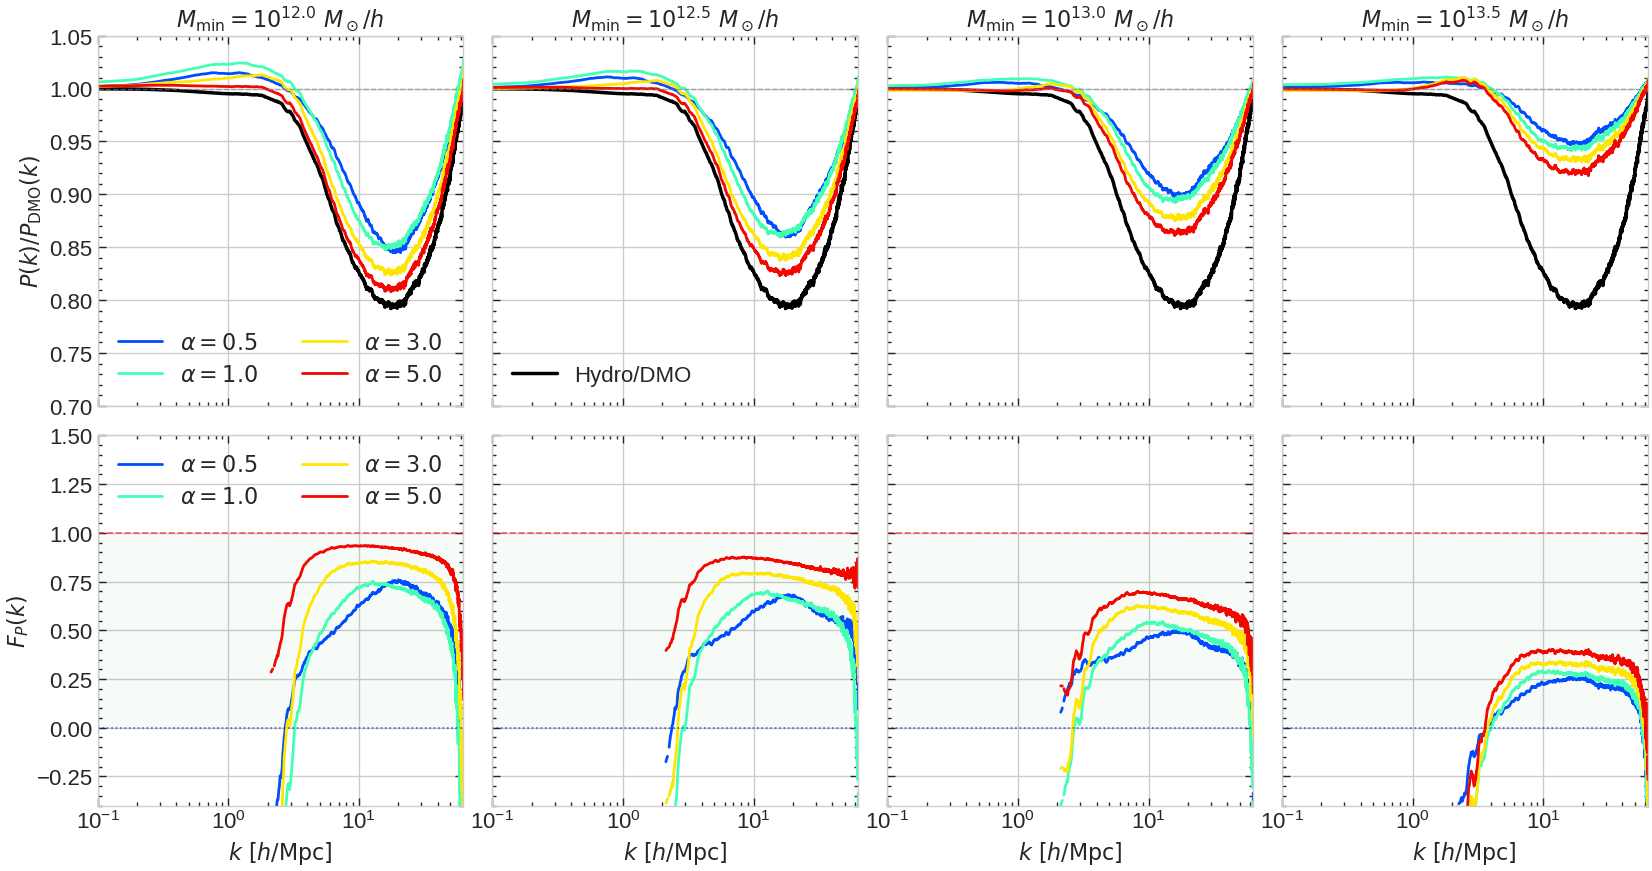

Figure 1: Scale-dependent response saved.


In [135]:
# =============================================================================
# FIGURE 1: P(k) ratios + F_P(k) panels (scale-dependent response)
# =============================================================================
# Row 0: 4 power spectrum ratio panels (P_hydro/P_dmo black, P_replace/P_dmo colored)
# Row 1: 4 scale-dependent F_P(k) panels (share x-axis with row 0)

from scipy.ndimage import uniform_filter1d

def smooth_logk(k_arr, y_arr, window=7):
    """Smooth y(k) with a uniform moving average (handles NaN via interpolation)."""
    valid = ~np.isnan(y_arr)
    if valid.sum() < window:
        return y_arr
    y_smooth = np.full_like(y_arr, np.nan)
    y_smooth[valid] = uniform_filter1d(y_arr[valid], size=window, mode='nearest')
    return y_smooth

if dmo_stats and hydro_stats and cumulative_models:
    k_range = (1.0, 30.0)

    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 4, height_ratios=[1, 1], hspace=0.08, wspace=0.08)

    k = dmo_stats['k']
    P_d = dmo_stats['Pk']
    P_h = hydro_stats['Pk']
    Delta_P = P_h - P_d
    significant = np.abs(Delta_P) > BARYONIC_THRESHOLD * np.abs(P_d)
    colors_alpha = plt.cm.jet(np.linspace(0.2, 0.9, len(RADII)))

    # -------------------------------------------------------------------------
    # Row 0: Power spectrum ratios P/P_dmo (4 panels)
    # -------------------------------------------------------------------------
    ax_ratio = [fig.add_subplot(gs[0, j]) for j in range(4)]
    for j in range(1, 4):
        ax_ratio[j].sharey(ax_ratio[0])
        ax_ratio[j].sharex(ax_ratio[0])

    ratio_hydro = P_h / P_d
    ratio_hydro_smooth = smooth_logk(k, ratio_hydro, window=9)

    for ax_idx, ml in enumerate(MASS_THRESHOLDS):
        ax = ax_ratio[ax_idx]
        if ax_idx ==1:
            ax.semilogx(k, ratio_hydro_smooth, lw=2.5, color='black', label=r'Hydro/DMO')
            ax.legend()
        else:
            ax.semilogx(k, ratio_hydro_smooth, lw=2.5, color='black')

        for r_idx, r in enumerate(RADII):
            key = (ml, r)
            if key in cumulative_models:
                P_r = cumulative_models[key]['Pk']
                ratio_r = P_r / P_d
                ratio_r_smooth = smooth_logk(k, ratio_r, window=9)
                ax.semilogx(k, ratio_r_smooth, lw=2, color=colors_alpha[r_idx], label=fr'$\alpha={r}$')
        ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.6)
        mass_log = np.log10(float(ml))
        ax.set_title(fr'$M_{{\rm min}}=10^{{{mass_log:.1f}}}\ M_\odot/h$')
        ax.set_xlim(0.1, NYQUIST)
        ax.set_ylim(0.7, 1.05)
        if ax_idx == 0:
            ax.legend(loc='lower left', ncol=2)
        if ax_idx==0:
            ax.set_ylabel(r'$P(k)/P_{\rm DMO}(k)$')

        else:
            plt.setp(ax.get_yticklabels(), visible=False)

    # -------------------------------------------------------------------------
    # Row 1: F_P(k) for each M_min (4 panels) - share x with row 0
    # -------------------------------------------------------------------------
    ax_fk = [fig.add_subplot(gs[1, j], sharex=ax_ratio[j]) for j in range(4)]
    for j in range(1, 4):
        ax_fk[j].sharey(ax_fk[0])

    # Hide x-tick labels on row 0 (shared with row 1)
    for ax in ax_ratio:
        plt.setp(ax.get_xticklabels(), visible=False)

    for ax_idx, ml in enumerate(MASS_THRESHOLDS):
        ax = ax_fk[ax_idx]
        for r_idx, r in enumerate(RADII):
            key = (ml, r)
            if key in cumulative_models:
                P_r = cumulative_models[key]['Pk']
                F_k = np.full_like(k, np.nan)
                F_k[significant] = (P_r[significant] - P_d[significant]) / Delta_P[significant]
                F_k_smooth = smooth_logk(k, F_k, window=9)
                ax.semilogx(k, F_k_smooth, lw=2, color=colors_alpha[r_idx], label=fr'$\alpha={r}$')
        ax.axhline(1.0, color='red', ls='--', lw=1.2, alpha=0.6)
        ax.axhline(0.0, color='blue', ls=':', lw=1.2, alpha=0.6)
        ax.axhspan(0, 1, alpha=0.03, color='green')
        ax.set_xlim(0.1, NYQUIST)
        ax.set_ylim(-0.4, 1.5)
        if ax_idx == 0:
            ax.set_ylabel(r'$F_P(k)$')
            ax.legend(loc='upper left', ncol=2)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)
        ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')

    plt.tight_layout()
    plt.savefig('/mnt/home/mlee1/hydro_replace2/notebooks/figures/scale_dependent_response.pdf')
    plt.show()
    print('Figure 1: Scale-dependent response saved.')
else:
    print('⚠ Not enough data')

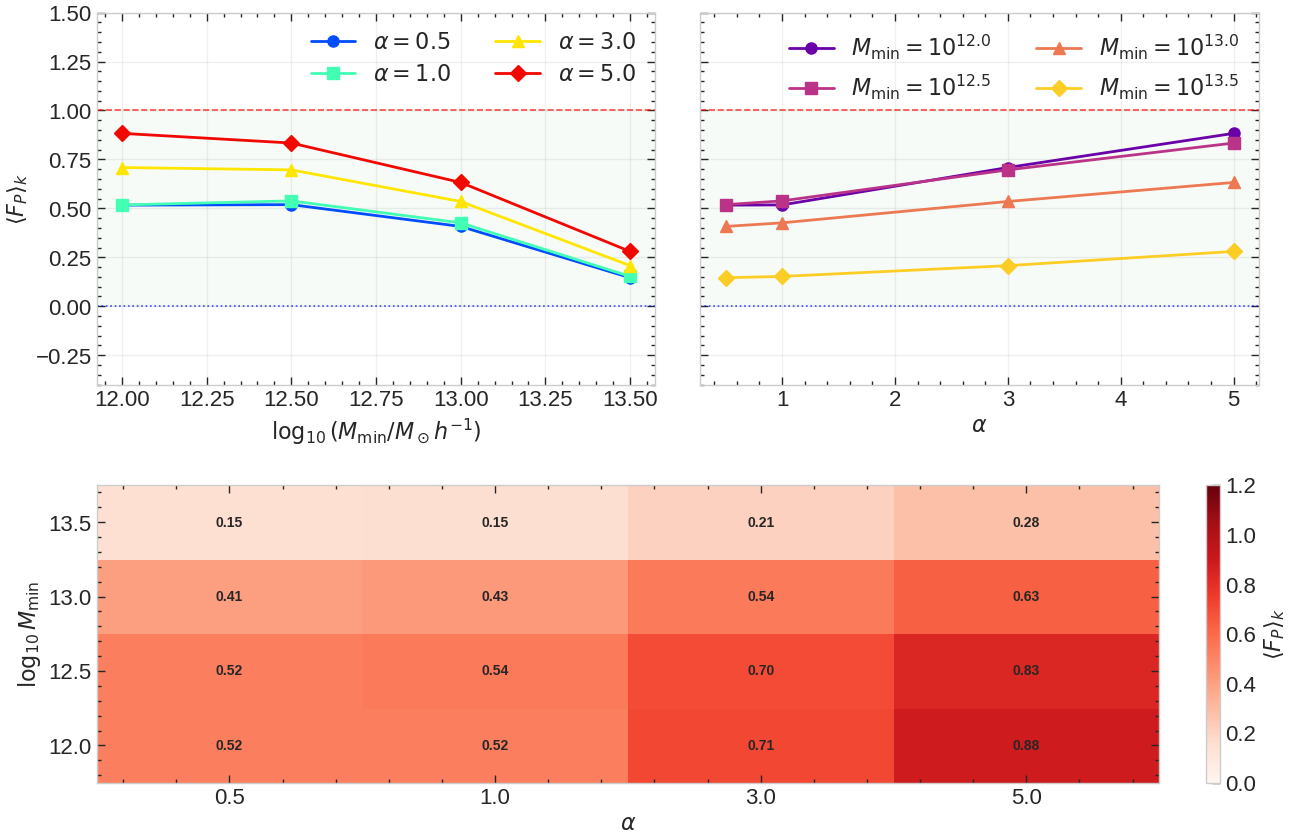

Figure 2: Cumulative response summary saved.


In [137]:
# =============================================================================
# FIGURE 2: Cumulative response panels + heatmap
# =============================================================================
# Row 0: 2 cumulative response panels (fixed α / fixed M_min)
# Row 1: heatmap spanning full width

if dmo_stats and hydro_stats and cumulative_models:
    # Precompute heatmap matrix
    n_mass = len(MASS_THRESHOLDS)
    n_alpha = len(RADII)
    F_Pk = np.full((n_mass, n_alpha), np.nan)
    k_range = (1.0, 30.0)
    for i, ml in enumerate(MASS_THRESHOLDS):
        for j, r in enumerate(RADII):
            key = (ml, r)
            if key in cumulative_models:
                F_Pk[i, j] = compute_response_fraction_Pk_mean(
                    cumulative_models[key], dmo_stats, hydro_stats, k_range=k_range
                )

    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.8], hspace=0.3, wspace=0.08)

    colors_alpha = plt.cm.jet(np.linspace(0.2, 0.9, len(RADII)))
    colors_mass = plt.cm.plasma(np.linspace(0.2, 0.9, len(MASS_THRESHOLDS)))
    markers = ['o', 's', '^', 'D']

    # -------------------------------------------------------------------------
    # Row 0: Cumulative response (2 panels)
    # -------------------------------------------------------------------------
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)

    # Left: fixed α, varying M_min
    for r_idx, r in enumerate(RADII):
        means = [compute_response_fraction_Pk_mean(cumulative_models.get((ml, r)), dmo_stats, hydro_stats, k_range=k_range) for ml in MASS_THRESHOLDS]
        ax0.plot(LOG_MASS, means, marker=markers[r_idx], color=colors_alpha[r_idx], lw=2, ms=8, label=fr'$\alpha={r}$')
    ax0.set_xlabel(r'$\log_{10}(M_{\rm min}/M_\odot h^{-1})$')
    ax0.set_ylabel(r'$\langle F_P \rangle_k$')

    # Right: fixed M_min, varying α
    for m_idx, ml in enumerate(MASS_THRESHOLDS):
        means = [compute_response_fraction_Pk_mean(cumulative_models.get((ml, r)), dmo_stats, hydro_stats, k_range=k_range) for r in RADII]
        ax1.plot(ALPHA_VALUES, means, marker=markers[m_idx], color=colors_mass[m_idx], lw=2, ms=8, label=r'$M_{\rm min}=$' + MASS_LABELS[m_idx])
    ax1.set_xlabel(r'$\alpha$')
    plt.setp(ax1.get_yticklabels(), visible=False)

    for ax in (ax0, ax1):
        ax.axhline(1.0, color='red', ls='--', lw=1.2, alpha=0.7)
        ax.axhline(0.0, color='blue', ls=':', lw=1.2, alpha=0.7)
        ax.set_ylim(-0.4, 1.5)
        ax.grid(True, alpha=0.3)
        ax.axhspan(0, 1, alpha=0.03, color='green')
    ax0.legend(loc='best', ncol=2)
    ax1.legend(loc='best', ncol=2)

    # -------------------------------------------------------------------------
    # Row 1: Heatmap spanning both columns
    # -------------------------------------------------------------------------
    ax2 = fig.add_subplot(gs[1, :])
    im = ax2.imshow(F_Pk, cmap='Reds', vmin=0, vmax=1.2, aspect='auto', origin='lower')
    ax2.set_xticks(range(n_alpha))
    ax2.set_xticklabels(RADII)
    ax2.set_yticks(range(n_mass))
    ax2.set_yticklabels([f'{np.log10(float(m)):.1f}' for m in MASS_THRESHOLDS])
    ax2.set_xlabel(r'$\alpha$')
    ax2.set_ylabel(r'$\log_{10}M_{\rm min}$')
    ax2.grid(False)
    for i in range(n_mass):
        for j in range(n_alpha):
            val = F_Pk[i, j]
            if not np.isnan(val):
                ax2.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\langle F_P \rangle_k$')

    plt.tight_layout()
    plt.savefig('/mnt/home/mlee1/hydro_replace2/notebooks/figures/cumulative_response_summary.pdf')
    plt.show()
    print('Figure 2: Cumulative response summary saved.')
else:
    print('⚠ Not enough data')

---
## Redshift Evolution Visualizations

We now explore how the response fraction $\langle F_P \rangle_k$ evolves with redshift across 20 snapshots from $z \approx 2.3$ to $z \approx 0$.

**Four visualization approaches:**
1. **Heatmaps** with redshift on x-axis
2. **Line plots** of $\langle F_P \rangle$ vs $z$
3. **Contour plots** at representative redshifts
4. **Ridge/waterfall plots** with stacked curves

In [143]:
# =============================================================================
# Build F_P(M_min, α, z) data cube for all visualizations
# =============================================================================

# Data cube dimensions
n_mass = len(MASS_THRESHOLDS)
n_alpha = len(RADII)
n_snap = len(SNAPSHOT_LIST)
k_range = (1.0, 30.0)

# F_cube[i_mass, j_alpha, k_snap] = mean response fraction
F_cube = np.full((n_mass, n_alpha, n_snap), np.nan)

# Corresponding redshifts for each snapshot index
z_array = np.array([SNAPSHOT_TO_Z[SNAPSHOT_LIST[s]] for s in range(n_snap)])

print(f"Building F_P data cube: {n_mass} masses × {n_alpha} radii × {n_snap} snapshots")
print(f"Redshift range: z = {z_array.min():.2f} to {z_array.max():.2f}")

for s_idx, snap_num in enumerate(SNAPSHOT_LIST):
    z = SNAPSHOT_TO_Z[snap_num]
    
    # Load baselines for this snapshot
    dmo_z = load_model_stats('dmo', snapshot_id=s_idx)
    hydro_z = load_model_stats('hydro', snapshot_id=s_idx)
    
    if dmo_z is None or hydro_z is None:
        print(f"  Snapshot {snap_num} (z={z:.2f}): missing baselines, skipping")
        continue
    
    for i, ml in enumerate(MASS_THRESHOLDS):
        for j, r in enumerate(RADII):
            model_name = f'hydro_replace_Ml_{ml}_Mu_inf_R_{r}'
            replace_z = load_model_stats(model_name, snapshot_id=s_idx)
            
            F = compute_response_fraction_Pk_mean(replace_z, dmo_z, hydro_z, k_range=k_range)
            F_cube[i, j, s_idx] = F
    
    n_valid = np.sum(~np.isnan(F_cube[:, :, s_idx]))
    print(f"  Snapshot {snap_num:3d} (z={z:.2f}): {n_valid}/{n_mass*n_alpha} valid values")

print(f"\n✓ Data cube built: {np.sum(~np.isnan(F_cube))}/{F_cube.size} valid entries")

Building F_P data cube: 4 masses × 4 radii × 20 snapshots
Redshift range: z = 0.02 to 2.32
  Snapshot  96 (z=0.02): 16/16 valid values
  Snapshot  90 (z=0.10): 16/16 valid values
  Snapshot  85 (z=0.18): 16/16 valid values


  Snapshot  80 (z=0.27): 16/16 valid values
  Snapshot  76 (z=0.35): 16/16 valid values
  Snapshot  71 (z=0.46): 16/16 valid values
  Snapshot  67 (z=0.55): 16/16 valid values
  Snapshot  63 (z=0.65): 16/16 valid values
  Snapshot  59 (z=0.76): 16/16 valid values
  Snapshot  56 (z=0.85): 16/16 valid values
  Snapshot  52 (z=0.97): 16/16 valid values
  Snapshot  49 (z=1.08): 16/16 valid values
  Snapshot  46 (z=1.21): 16/16 valid values
  Snapshot  43 (z=1.36): 16/16 valid values
  Snapshot  41 (z=1.47): 16/16 valid values
  Snapshot  38 (z=1.63): 16/16 valid values
  Snapshot  35 (z=1.82): 16/16 valid values
  Snapshot  33 (z=1.97): 16/16 valid values
  Snapshot  31 (z=2.14): 16/16 valid values
  Snapshot  29 (z=2.32): 16/16 valid values

✓ Data cube built: 320/320 valid entries


### Option 2: Line Plots of ⟨F_P⟩ vs Redshift

Four panels (one per α), each showing lines for different $M_{\rm min}$ values.

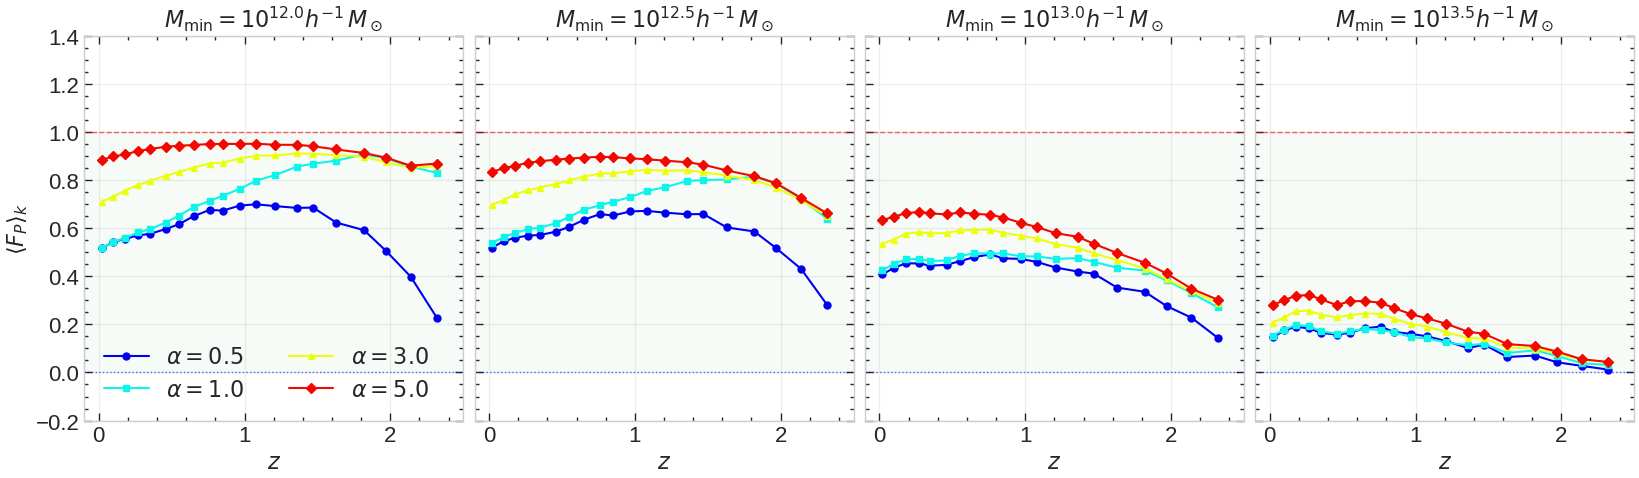

Option 2 saved.


In [164]:
# =============================================================================
# OPTION 2: Line plots of ⟨F_P⟩ vs redshift
# =============================================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True, gridspec_kw={'wspace':0.03})

colors_alpha = plt.cm.jet(np.linspace(0.1, 0.9, n_alpha))
markers = ['o', 's', '^', 'D']
alpha_labels = [fr'$\alpha = {r}$' for r in RADII]

# Loop over mass thresholds (subplots)
for ax_idx, (i, ml) in enumerate(zip(range(n_mass), MASS_THRESHOLDS)):
    ax = axes.flat[ax_idx]
    
    # Loop over alpha values (lines)
    for j, (r, alpha_label) in enumerate(zip(RADII, alpha_labels)):
        F_vs_z = F_cube[i, j, :]
        valid = ~np.isnan(F_vs_z)
        
        ax.plot(z_array[valid], F_vs_z[valid], marker=markers[j], ms=5, lw=1.5,
                color=colors_alpha[j], label=alpha_label)
    
    ax.axhline(1.0, color='red', ls='--', lw=1, alpha=0.6)
    ax.axhline(0.0, color='blue', ls=':', lw=1, alpha=0.6)
    ax.set_title(r'$M_{\rm min} = $' + MASS_LABELS[i] + r'$h^{-1}\,M_\odot$')
    ax.grid(True, alpha=0.3)
    ax.axhspan(0, 1, alpha=0.03, color='green')

    
    # if ax_idx >= 2:
    ax.set_xlabel('$z$')
    if ax_idx  == 0:
        ax.set_ylabel(r'$\langle F_P \rangle_k$')

axes[0].legend(loc='lower left', ncols=2)
axes[0].set_xlim(-0.1, 2.5)
axes[0].set_ylim(-0.2, 1.4)

# plt.suptitle(r'Response Fraction vs Redshift', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/mnt/home/mlee1/hydro_replace2/notebooks/figures/redshift_evolution.pdf')
plt.show()
print('Option 2 saved.')